# Chapter 12 — Diffusion Transformers (DiT)

In Chapter 8 you built a generative model out of two pieces: a **fixed** forward
process that destroys images with Gaussian noise, and a **learned** denoiser
that predicts the noise so the process can be run backwards. The denoiser was a
U-Net, because in 2020 that was the only sensible choice for a network whose
output must be the same shape as its input.

This chapter replaces it. The forward process, the training objective, and the
sampling loop are **completely unchanged**, and every equation you derived there
still holds. Only the denoiser's architecture changes, from a convolutional
U-Net to a Transformer operating on image patches.

That substitution is the DiT (Peebles & Xie, 2022), and it is the architecture
behind **Stable Diffusion 3, Flux, and Sora**. It is also the payoff for
Chapters 9–11: you already have every component except one.

**The one new idea is conditioning.** A classifier gets an image and returns a
label. A denoiser gets an image *and a timestep*, and often a class or a text
prompt, and those extras have to reach every layer. The U-Net handled it by
adding a bias to feature maps. The DiT does something considerably more
effective, and it is a modification of the LayerNorm you built in Chapter 10:

$$ \text{AdaLN}(h, c) = \gamma(c) \odot \frac{h - \mu}{\sigma} + \beta(c) $$

The scale and shift stop being free parameters and become **functions of the
conditioning**. Module 3 builds it; Module 5 measures whether it was worth it.

| Module | What you build | Dataset (Hugging Face) |
|---|---|---|
| 1 | The diffusion machinery, recovered in a dozen lines | `zalando-datasets/fashion_mnist` |
| 2 | **Patchify** a noisy image, and un-patchify a noise prediction |  — |
| 3 | **adaLN-Zero**: the conditioning mechanism at the heart of the DiT | — |
| 4 | The complete DiT block and model | — |
| 5 | **An ablation**: does adaLN-Zero actually pay for itself? | `fashion_mnist` |
| 6 | Training the denoiser | `fashion_mnist` |
| 7 | **Reverse sampling**: pure static → clothing | — |
| 8 | **Classifier-free guidance**, on a Transformer this time | — |

> 🧠 **The intuition:** the idea in plain language, no symbols.
> 📐 **The math:** the same idea written precisely, so you can read papers.
> 💻 **The code:** the same idea again, executable, in the cell that follows.

**Runtime:** ~13 minutes on a GPU, and it is worth knowing where it goes: about
5 minutes for the three-way ablation in Module 5, about 7 for the real training
run in Module 6, and the rest in sampling. Generating 40 images takes ~3 s. To
cut it down, set `ABLATION_EPOCHS = 4` and `EPOCHS = 15`: the conclusions
survive, the samples get blurrier. Fashion-MNIST is already cached from
Chapters 5–7.


In [1]:
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset

torch.manual_seed(42)
plt.rcParams["figure.figsize"] = (7, 4.5)
device = "cuda" if torch.cuda.is_available() else "cpu"

print("PyTorch", torch.__version__, "| device:", device)

/home/mujtaba/venvs/datasci/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch 2.11.0+cu128 | device: cuda


---
# Module 1 — The Diffusion Machinery, Unchanged

🧠 **The intuition**, compressed from Chapter 8. Destroying an image is free and
exact: add a little Gaussian noise, repeat. The closed form lets you jump
straight to any noise level $t$ in one step, so producing a training example at
$t = 380$ costs no more than at $t = 5$. The network's job is to look at a
corrupted image, be told which $t$ it is at, and name the noise that was added.
Plain MSE.

📐 **The math**, also unchanged. With $\alpha_t = 1 - \beta_t$ and $\bar\alpha_t
= \prod_{s \le t} \alpha_s$:

$$ x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1 - \bar\alpha_t}\, \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, I) $$

$$ \mathcal{L} = \mathbb{E}_{x_0,\, t,\, \varepsilon} \big\| \varepsilon - \varepsilon_\theta(x_t, t, c) \big\|^2 $$

The **only** difference from Chapter 8 is what sits inside $\varepsilon_\theta$.
Everything outside it (schedule, objective, sampler) is identical, which is
exactly why swapping architectures is a tractable thing to do at all.

💻 **The code.** We use Fashion-MNIST rather than MNIST: same shape, same cost,
but garments have texture and internal structure, which makes it much easier to
judge whether samples are genuinely good or merely blob-shaped.


In [2]:
fashion = load_dataset("zalando-datasets/fashion_mnist")
CLASS_NAMES = fashion["train"].features["label"].names
print(CLASS_NAMES)

imgs = np.stack([np.array(im) for im in fashion["train"]["image"]])
X = torch.tensor(imgs).float()[:, None] / 127.5 - 1.0        # (N, 1, 28, 28) in [-1, 1]
Y = torch.tensor(list(fashion["train"]["label"]))
N_CLASSES = len(CLASS_NAMES)

print("\ntrain:", tuple(X.shape), "| range:", X.min().item(), "to", X.max().item())
print("[-1, 1] again, for the same reason as before: the forward process assumes")
print("roughly unit variance so that x_T lands on N(0, I).")

['T - shirt / top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']



train: (60000, 1, 28, 28) | range: -1.0 to 1.0
[-1, 1] again, for the same reason as before: the forward process assumes
roughly unit variance so that x_T lands on N(0, I).


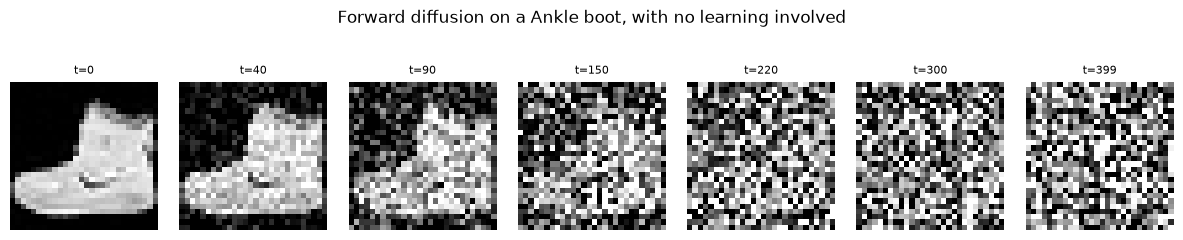

In [3]:
T = 400                                    # <- knob: diffusion steps
betas = torch.linspace(1e-4, 0.04, T)      # the linear schedule from Chapter 8
alphas = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0)


def forward_diffuse(x0, t, noise=None):
    '''x_t = sqrt(abar_t) x_0 + sqrt(1 - abar_t) eps: the closed form.'''
    noise = torch.randn_like(x0) if noise is None else noise
    ab = alpha_bar.to(x0.device)[t][:, None, None, None]
    return ab.sqrt() * x0 + (1 - ab).sqrt() * noise


steps = [0, 40, 90, 150, 220, 300, T - 1]
fig, axes = plt.subplots(1, len(steps), figsize=(12, 2.1))
for ax, t in zip(axes, steps):
    xt = forward_diffuse(X[:1], torch.tensor([t]))
    ax.imshow(xt[0, 0], cmap="gray", vmin=-1, vmax=1)
    ax.set_title(f"t={t}", fontsize=8); ax.axis("off")
fig.suptitle(f"Forward diffusion on a {CLASS_NAMES[Y[0]]}, with no learning involved", y=1.12)
plt.tight_layout(); plt.show()

---
# Module 2 — The Image as a Sequence, Again

🧠 **The intuition.** Chapter 11 turned an image into patches to classify it.
Here we do the same thing to *denoise* it, and there is one new requirement: the
output must be an image, not a label. So we need to run the process backwards as
well, taking the Transformer's per-token outputs and reassembling them into a
28×28 noise prediction. Patchify in, un-patchify out.

**Choosing the patch size is the central cost decision in a DiT**, and it works
opposite to the way it does in classification. In Chapter 11 a bigger patch
mainly cost you spatial resolution in the *features*. Here it costs you
resolution in the **output**, since the model emits one $P \times P$ block of
noise per token, so $P = 4$ means predicting sixteen noise values from a single
vector. The DiT paper found patch size to be the strongest lever on sample
quality of anything they varied, and used $P = 2$ for their best models.

We use $P = 2$: a $14 \times 14$ grid, so 196 tokens. That is about three times
the sequence length of Chapter 11's ViT, and (by Chapter 9, Module 6) roughly
**nine times** the attention cost, which is where this notebook's runtime goes.

📐 **The math.** Patchify is a reshape; un-patchify is its exact inverse:

$$ \underbrace{(B, C, H, W)}_{\text{noisy image}} \;\longrightarrow\; \underbrace{(B, N, P^2 C)}_{\text{token sequence}} \quad\text{with}\quad N = \frac{HW}{P^2} $$

💻 **The code.** The correctness test that matters: patchify then un-patchify
must return the original tensor, bit for bit.


In [4]:
PATCH = 2                                  # <- knob: 4 is ~4x faster and visibly worse
IMG_SIZE, CHANNELS = 28, 1
GRID = IMG_SIZE // PATCH
N_TOKENS = GRID * GRID


def patchify(x, patch=PATCH):
    B, Cc, H, W = x.shape
    g = H // patch
    x = x.reshape(B, Cc, g, patch, g, patch)
    x = x.permute(0, 2, 4, 1, 3, 5)                      # (B, gh, gw, C, p, p)
    return x.reshape(B, g * g, Cc * patch * patch)


def unpatchify(z, patch=PATCH, channels=CHANNELS):
    B, N, _ = z.shape
    g = int(math.sqrt(N))
    z = z.reshape(B, g, g, channels, patch, patch)
    z = z.permute(0, 3, 1, 4, 2, 5)                      # (B, C, gh, p, gw, p)
    return z.reshape(B, channels, g * patch, g * patch)


probe = X[:4]
seq = patchify(probe)
back = unpatchify(seq)

print(f"image  {tuple(probe.shape)}")
print(f"tokens {tuple(seq.shape)}   <- {N_TOKENS} tokens of {PATCH * PATCH * CHANNELS} values")
print(f"back   {tuple(back.shape)}")
print(f"\nround-trip exact: {torch.equal(probe, back)}")
print(f"attention cost vs Chapter 11's ViT: ({N_TOKENS}/64)² = {(N_TOKENS / 64) ** 2:.0f}x")

image  (4, 1, 28, 28)
tokens (4, 196, 4)   <- 196 tokens of 4 values
back   (4, 1, 28, 28)

round-trip exact: True
attention cost vs Chapter 11's ViT: (196/64)² = 9x


---
# Module 3 — Conditioning: The One Genuinely New Idea

## 3.1 The problem

🧠 **The intuition.** The denoiser needs to know two things that are not in the
image: **which timestep** it is at, and **which class** to generate. Both are
single vectors that must influence computation at every layer and every spatial
position. How do you inject a global signal into a stack of blocks?

In Chapter 8, the U-Net did the obvious thing, projecting the timestep embedding
to the channel count and **adding** it:

```python
t_bias = layers.Dense(filters)(t_emb)
h = layers.Add()([h, layers.Reshape((1, 1, filters))(t_bias)])
```

It works. But look at what it can express: a constant offset, added to every
position. It shifts features. It cannot *scale* them, cannot suppress a feature
at $t = 380$ and amplify it at $t = 20$, and cannot turn a whole sub-layer off.
Conditioning is doing a lot of work in a diffusion model, since the network's
behaviour at high $t$ and low $t$ genuinely should be different, and a bias term
is a thin channel for it.

## 3.2 Adaptive LayerNorm

🧠 **The intuition.** Chapter 10's LayerNorm ends by applying a learned scale
$\gamma$ and shift $\beta$ to the normalized features. Those are free
parameters: fixed after training, identical for every input.

**Make them functions of the conditioning instead.** A small MLP takes the
timestep-plus-class vector and *predicts* $\gamma$ and $\beta$. Now the network's
normalization behaviour is different at every timestep, and multiplicative, so
the model can scale a feature to zero at one noise level and amplify it at
another.

This is not a new invention for diffusion; it is **FiLM** (Perez et al., 2017),
and the same idea powers StyleGAN's AdaIN. The DiT's contribution is showing it
is the right way to condition a Transformer denoiser.

📐 **The math.** For a token's feature vector $h$ and conditioning vector $c$:

$$ \boxed{\;\text{AdaLN}(h, c) = \gamma(c) \odot \underbrace{\frac{h - \mu}{\sigma}}_{\text{LayerNorm, no affine}} + \;\beta(c)\;} $$

where $\gamma(c), \beta(c) = \text{MLP}(c)$. In code the LayerNorm is created
with `elementwise_affine=False`, since we are supplying the affine part
ourselves.

## 3.3 adaLN-**Zero**: the part that makes it train

🧠 **The intuition.** The DiT paper adds one more thing, and the name of the
architecture keeps the word "Zero" for it, so it clearly matters.

Alongside $\gamma$ and $\beta$, predict a third quantity: a **gate** $\alpha$
that scales the *entire sub-layer output* before it re-enters the residual
stream. Then initialize the MLP that produces it to **output exactly zero**.

Trace what that means at step 0 of training. Every gate is 0, so every residual
branch contributes nothing, so **each block computes the identity function** and
the whole deep network starts as a clean pass-through. Training then *opens the
gates gradually*, in whatever order helps.

This is the same insight as ResNet's zero-initialized final BatchNorm and
Fixup initialization, and the same "do nothing is the safe default" argument you
met in Chapter 3: a deep residual network is far easier to optimize if it begins
as an identity map and grows its depth rather than starting as a random function
of 6 stacked blocks.

📐 **The math.** Per block, the conditioning MLP emits **six** vectors: shift,
scale, and gate, for each of the two sub-layers.

$$ \begin{aligned} h &\leftarrow h + \alpha_1(c) \odot \text{Attention}\big(\gamma_1(c) \odot \text{LN}(h) + \beta_1(c)\big) \\ h &\leftarrow h + \alpha_2(c) \odot \text{MLP}\big(\gamma_2(c) \odot \text{LN}(h) + \beta_2(c)\big) \end{aligned} $$

with $\alpha_1, \alpha_2 = 0$ at initialization.

💻 **The code.** Both helpers are three lines.


In [5]:
def modulate(x, shift, scale):
    '''Apply predicted scale and shift. x: (B, N, d); shift/scale: (B, d).

    Note the (1 + scale): the MLP is zero-initialized, so at step 0 this is a
    multiply by 1 rather than by 0, and the features pass through untouched.'''
    return x * (1 + scale.unsqueeze(1)) + shift.unsqueeze(1)


def timestep_embedding(t, dim, max_period=10000.0):
    '''Sinusoidal embedding, identical to Chapter 8's and to Chapter 10's
    positional encoding. Same construction, third appearance.'''
    half = dim // 2
    freqs = torch.exp(-math.log(max_period) * torch.arange(half, device=t.device) / half)
    args = t.float()[:, None] * freqs[None]
    return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)


demo_t = torch.tensor([0, 50, 150, 399])
print("timestep embedding:", tuple(timestep_embedding(demo_t, 256).shape))

d_demo = 8
zero_mlp = nn.Sequential(nn.SiLU(), nn.Linear(d_demo, 3 * d_demo))
nn.init.zeros_(zero_mlp[1].weight); nn.init.zeros_(zero_mlp[1].bias)

shift, scale, gate = zero_mlp(torch.randn(2, d_demo)).chunk(3, dim=1)
print("\nat initialization, for any conditioning vector:")
print("  shift =", shift[0].detach().numpy().round(3))
print("  scale =", scale[0].detach().numpy().round(3), "-> modulate() multiplies by (1+0) = 1")
print("  gate  =", gate[0].detach().numpy().round(3), "-> the sub-layer contributes NOTHING")

timestep embedding: (4, 256)

at initialization, for any conditioning vector:
  shift = [0. 0. 0. 0. 0. 0. 0. 0.]
  scale = [0. 0. 0. 0. 0. 0. 0. 0.] -> modulate() multiplies by (1+0) = 1
  gate  = [0. 0. 0. 0. 0. 0. 0. 0.] -> the sub-layer contributes NOTHING


---
# Module 4 — The DiT Block and Model

💻 **The code.** Compare this against Chapter 10's `TransformerEncoderBlock`. The
attention and the MLP are untouched; the LayerNorms lost their affine parameters;
and six modulation vectors arrived. That is the complete diff.

In [6]:
class Attention(nn.Module):
    '''Chapter 10's multi-head self-attention, using torch's fused kernel.

    We built this from scratch in Chapter 10 and verified it matches torch exactly,
    so from here we use the fused version, which is faster and, at 196 tokens,
    that matters.'''

    def __init__(self, d_model, n_heads):
        super().__init__()
        self.n_heads, self.d_k = n_heads, d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model, bias=False)
        self.proj = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x):
        B, N, D = x.shape
        q, k, v = self.qkv(x).reshape(B, N, 3, self.n_heads, self.d_k).permute(2, 0, 3, 1, 4)
        out = F.scaled_dot_product_attention(q, k, v)          # (B, H, N, d_k)
        return self.proj(out.transpose(1, 2).reshape(B, N, D))


class DiTBlock(nn.Module):
    def __init__(self, d_model, n_heads, mlp_ratio=4):
        super().__init__()
        # note elementwise_affine=False, because adaLN supplies gamma and beta
        self.norm1 = nn.LayerNorm(d_model, elementwise_affine=False, eps=1e-6)
        self.attn = Attention(d_model, n_heads)
        self.norm2 = nn.LayerNorm(d_model, elementwise_affine=False, eps=1e-6)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, mlp_ratio * d_model),
            nn.GELU(approximate="tanh"),
            nn.Linear(mlp_ratio * d_model, d_model),
        )

        # the adaLN-Zero MLP: one conditioning vector in, six modulation vectors out
        self.adaLN = nn.Sequential(nn.SiLU(), nn.Linear(d_model, 6 * d_model))
        nn.init.zeros_(self.adaLN[1].weight)          # <- the "Zero" in adaLN-Zero
        nn.init.zeros_(self.adaLN[1].bias)

    def forward(self, x, c):
        shift_a, scale_a, gate_a, shift_m, scale_m, gate_m = self.adaLN(c).chunk(6, dim=1)

        x = x + gate_a.unsqueeze(1) * self.attn(modulate(self.norm1(x), shift_a, scale_a))
        x = x + gate_m.unsqueeze(1) * self.mlp(modulate(self.norm2(x), shift_m, scale_m))
        return x


# The identity claim from 3.3, checked rather than asserted.
blk = DiTBlock(64, 4)
h_in = torch.randn(2, N_TOKENS, 64)
c_in = torch.randn(2, 64)
h_out = blk(h_in, c_in)

print(f"max |output - input| at initialization: {(h_out - h_in).abs().max().item():.2e}")
assert torch.allclose(h_out, h_in)
print("✓ the block is exactly the identity at step 0, so a 6-block DiT starts as a pass-through")

max |output - input| at initialization: 0.00e+00
✓ the block is exactly the identity at step 0, so a 6-block DiT starts as a pass-through


In [7]:
class DiT(nn.Module):
    def __init__(self, img_size=IMG_SIZE, patch=PATCH, channels=CHANNELS,
                 d_model=256, depth=6, n_heads=4, n_classes=N_CLASSES, t_dim=256):
        super().__init__()
        self.patch, self.channels = patch, channels
        n_tokens = (img_size // patch) ** 2
        self.t_dim = t_dim

        # --- input: patches + learnable positions (Chapter 11)
        self.x_embed = nn.Linear(patch * patch * channels, d_model)
        self.pos_embed = nn.Parameter(torch.randn(1, n_tokens, d_model) * 0.02)

        # --- conditioning: timestep + class, summed into one vector c
        self.t_mlp = nn.Sequential(nn.Linear(t_dim, d_model), nn.SiLU(),
                                   nn.Linear(d_model, d_model))
        # n_classes + 1: the extra slot is the NULL class used by guidance (Module 8)
        self.y_embed = nn.Embedding(n_classes + 1, d_model)

        # --- body
        self.blocks = nn.ModuleList([DiTBlock(d_model, n_heads) for _ in range(depth)])

        # --- output: one more adaLN, then project back to pixels
        self.norm_out = nn.LayerNorm(d_model, elementwise_affine=False, eps=1e-6)
        self.adaLN_out = nn.Sequential(nn.SiLU(), nn.Linear(d_model, 2 * d_model))
        self.proj_out = nn.Linear(d_model, patch * patch * channels)
        for layer in (self.adaLN_out[1], self.proj_out):
            nn.init.zeros_(layer.weight); nn.init.zeros_(layer.bias)

    def forward(self, x, t, y):
        h = self.x_embed(patchify(x, self.patch)) + self.pos_embed
        c = self.t_mlp(timestep_embedding(t, self.t_dim)) + self.y_embed(y)

        for block in self.blocks:
            h = block(h, c)

        shift, scale = self.adaLN_out(c).chunk(2, dim=1)
        return unpatchify(self.proj_out(modulate(self.norm_out(h), shift, scale)),
                          self.patch, self.channels)


model = DiT()
eps_hat = model(X[:4], torch.tensor([10, 100, 200, 399]), Y[:4])
print("input", tuple(X[:4].shape), "-> predicted noise", tuple(eps_hat.shape))
print("same shape in, same shape out, as a denoiser must be\n")

total = sum(p.numel() for p in model.parameters())
ada = sum(p.numel() for n, p in model.named_parameters() if "adaLN" in n)
print(f"parameters: {total:,}")
print(f"  of which adaLN modulation MLPs: {ada:,}  ({ada / total:.0%})")
print("\nThat fraction is the honest cost of adaLN-Zero: roughly a third of the")
print("model exists purely to convert conditioning into modulation. Module 5 asks")
print("whether that is a good trade.")

input (4, 1, 28, 28) -> predicted noise (4, 1, 28, 28)
same shape in, same shape out, as a denoiser must be

parameters: 7,413,252
  of which adaLN modulation MLPs: 2,500,096  (34%)

That fraction is the honest cost of adaLN-Zero: roughly a third of the
model exists purely to convert conditioning into modulation. Module 5 asks
whether that is a good trade.


---
# Module 5 — Does adaLN-Zero Pay for Itself?

🧠 **The setup.** A third of the parameters going to conditioning is a strong
claim, and the DiT paper's central ablation tests exactly this. We can reproduce
it in a few minutes with three variants that differ *only* in how $c$ reaches the
blocks:

1. **additive (in-context):** add $c$ to the token embeddings once at the input,
   then use ordinary blocks with standard LayerNorm. This is closest in spirit to
   what the U-Net did, and it is the cheapest option.
2. **adaLN:** predict $\gamma, \beta$ per block, but no gate and no zero-init.
3. **adaLN-Zero:** the full mechanism, gates included, zero-initialized.

📐 **What to predict.** If the extra parameters buy nothing, all three land on
the same loss and the DiT paper is overselling. If conditioning bandwidth really
is the bottleneck, additive should be clearly worse.


In [8]:
class AdditiveBlock(nn.Module):
    '''Baseline: ordinary Chapter 10 block. Conditioning never reaches it directly.'''

    def __init__(self, d_model, n_heads, mlp_ratio=4):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = Attention(d_model, n_heads)
        self.norm2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, mlp_ratio * d_model), nn.GELU(approximate="tanh"),
            nn.Linear(mlp_ratio * d_model, d_model),
        )

    def forward(self, x, c):
        x = x + self.attn(self.norm1(x))
        return x + self.mlp(self.norm2(x))


class AdaLNNoZeroBlock(DiTBlock):
    '''adaLN with the zero-init removed, so gates start random and no identity.'''

    def __init__(self, d_model, n_heads, mlp_ratio=4):
        super().__init__(d_model, n_heads, mlp_ratio)
        nn.init.normal_(self.adaLN[1].weight, std=0.02)
        nn.init.zeros_(self.adaLN[1].bias)


class DiTVariant(DiT):
    def __init__(self, kind, d_model=256, depth=6, n_heads=4, **kw):
        super().__init__(d_model=d_model, depth=depth, n_heads=n_heads, **kw)
        self.kind = kind
        if kind == "additive":
            self.blocks = nn.ModuleList([AdditiveBlock(d_model, n_heads) for _ in range(depth)])
        elif kind == "adaLN":
            self.blocks = nn.ModuleList([AdaLNNoZeroBlock(d_model, n_heads) for _ in range(depth)])

    def forward(self, x, t, y):
        h = self.x_embed(patchify(x, self.patch)) + self.pos_embed
        c = self.t_mlp(timestep_embedding(t, self.t_dim)) + self.y_embed(y)
        if self.kind == "additive":
            h = h + c.unsqueeze(1)                       # the only injection point
        for block in self.blocks:
            h = block(h, c)
        shift, scale = self.adaLN_out(c).chunk(2, dim=1)
        return unpatchify(self.proj_out(modulate(self.norm_out(h), shift, scale)),
                          self.patch, self.channels)


for k in ("additive", "adaLN", "adaLN-Zero"):
    m = DiT() if k == "adaLN-Zero" else DiTVariant(k)
    print(f"{k:>12}: {sum(p.numel() for p in m.parameters()):>10,} parameters")

    additive:  5,050,884 parameters
       adaLN:  7,413,252 parameters


  adaLN-Zero:  7,413,252 parameters


In [9]:
BATCH = 256
LABEL_DROP = 0.1          # fraction of labels replaced by the null class (for Module 8)


def train_denoiser(model, epochs, lr=3e-4, log_every=None, seed=0):
    '''The training loop from Chapter 8, in PyTorch.'''
    torch.manual_seed(seed)
    model = model.to(device)
    ab = alpha_bar.to(device)
    Xd, Yd = X.to(device), Y.to(device)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.0)
    total_steps = epochs * math.ceil(len(Xd) / BATCH)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, lr, total_steps=total_steps, pct_start=0.05)

    losses, t0 = [], time.time()
    for ep in range(epochs):
        model.train()
        perm = torch.randperm(len(Xd), device=device)
        running = 0.0
        for i in range(0, len(Xd), BATCH):
            idx = perm[i:i + BATCH]
            x0, y = Xd[idx], Yd[idx].clone()

            # drop 10% of labels to the null class, which trains the unconditional model
            y[torch.rand(len(y), device=device) < LABEL_DROP] = N_CLASSES

            t = torch.randint(0, T, (len(x0),), device=device)      # random timestep per image
            eps = torch.randn_like(x0)                              # the target
            xt = forward_diffuse(x0, t, eps)                        # the input

            loss = F.mse_loss(model(xt, t, y), eps)                 # plain MSE. That is all.

            opt.zero_grad()
            loss.backward()
            opt.step()
            sched.step()
            running += loss.item() * len(x0)

        losses.append(running / len(Xd))
        if log_every and (ep % log_every == 0 or ep == epochs - 1):
            print(f"  epoch {ep + 1}/{epochs}  loss {losses[-1]:.4f}  ({time.time() - t0:.0f}s)")
    return losses


ABLATION_EPOCHS = 8            # <- knob: enough to separate the variants
ablation = {}
for kind in ("additive", "adaLN", "adaLN-Zero"):
    torch.manual_seed(0)                       # seed BEFORE construction so inits match
    net = DiT() if kind == "adaLN-Zero" else DiTVariant(kind)
    ablation[kind] = train_denoiser(net, ABLATION_EPOCHS)
    print(f"{kind:>12}: final loss {ablation[kind][-1]:.4f}")

    additive: final loss 0.0627


       adaLN: final loss 0.0513


  adaLN-Zero: final loss 0.0503


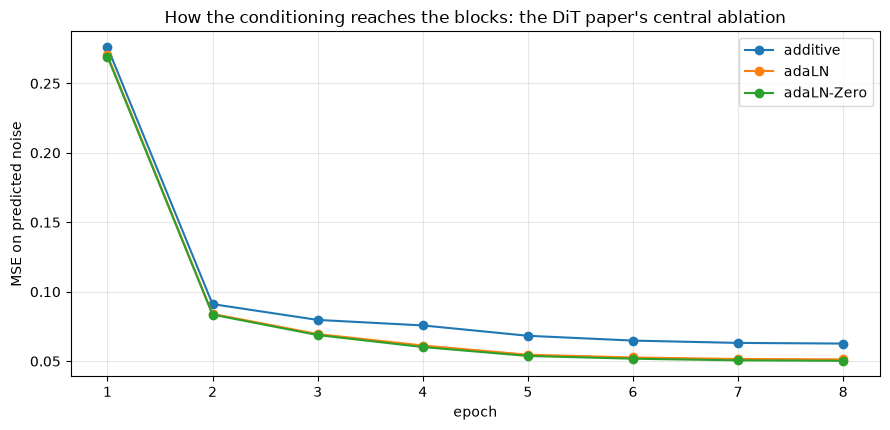

additive   : 0.0627
adaLN      : 0.0513   (18.2% lower loss than additive)
adaLN-Zero : 0.0503   (19.8% lower loss than additive)


In [10]:
plt.figure(figsize=(9, 4.4))
for kind, losses in ablation.items():
    plt.plot(range(1, len(losses) + 1), losses, marker="o", label=kind)
plt.xlabel("epoch"); plt.ylabel("MSE on predicted noise")
plt.title("How the conditioning reaches the blocks: the DiT paper's central ablation")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

add, ada, adaz = (ablation[k][-1] for k in ("additive", "adaLN", "adaLN-Zero"))
print(f"additive   : {add:.4f}")
print(f"adaLN      : {ada:.4f}   ({(add - ada) / add:.1%} lower loss than additive)")
print(f"adaLN-Zero : {adaz:.4f}   ({(add - adaz) / add:.1%} lower loss than additive)")

**Additive conditioning is clearly and consistently worse.** Adding $c$ once at
the input, the cheapest option and the one closest to what the U-Net did,
leaves the model measurably behind for the whole run. The conditioning pathway
really is a bottleneck, and widening it really does pay. That is the ablation
reproducing.

**The two adaLN variants land close together**, and it is worth being precise
about what that does and does not show. Zero-init is a claim about
*optimization*, that starting from the identity makes a deep residual stack
easier to train, and its benefit grows with depth. At 6 blocks there is not much
depth for it to rescue; the DiT paper's models are 12 to 28 blocks deep, where
the gap widens. Our measurement is consistent with the paper without
independently confirming that part of it, and it would be overclaiming to say
otherwise.

**One caveat to keep the comparison honest.** The three variants do not have
equal parameter counts, since the adaLN models carry those modulation MLPs,
about **47% more weight** than the additive baseline (7.4M vs 5.1M, printed
above). So this is not a controlled test of *architecture at fixed capacity*; it
is a test of *where to spend a parameter budget*. The DiT paper
addresses this directly by comparing at matched Gflops and finds adaLN-Zero still
wins. Ours is the weaker version of that claim, and worth flagging as such.


---
# Module 6 — Training the Denoiser

💻 Now train the real model. Note what the loop is *not* doing: no adversary, no
KL term, no sampling during training, no discriminator schedule. One MSE, one
optimizer, one backward pass, the same dull, stable loop as Chapter 8, which
remains the strongest practical argument for the whole approach.


In [11]:
EPOCHS = 30                    # <- knob: 15 gives recognisable-but-soft garments

dit = DiT()
print(f"training a {sum(p.numel() for p in dit.parameters()):,}-parameter DiT "
      f"on {len(X):,} images for {EPOCHS} epochs")
history = train_denoiser(dit, EPOCHS, log_every=5)

training a 7,413,252-parameter DiT on 60,000 images for 30 epochs


  epoch 1/30  loss 0.4242  (14s)


  epoch 6/30  loss 0.0533  (83s)


  epoch 11/30  loss 0.0473  (153s)


  epoch 16/30  loss 0.0447  (220s)


  epoch 21/30  loss 0.0434  (288s)


  epoch 26/30  loss 0.0427  (355s)


  epoch 30/30  loss 0.0425  (408s)


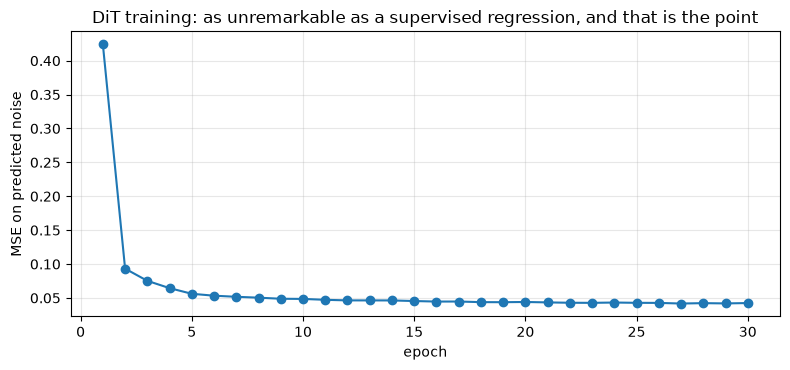

final loss: 0.0425


In [12]:
plt.figure(figsize=(8, 3.8))
plt.plot(range(1, len(history) + 1), history, marker="o")
plt.xlabel("epoch"); plt.ylabel("MSE on predicted noise")
plt.title("DiT training: as unremarkable as a supervised regression, and that is the point")
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f"final loss: {history[-1]:.4f}")

## 6.1 Does it denoise?

💻 Before running the full 400-step sampler, a cheap sanity check: corrupt real
images to a known timestep, ask the model for the noise, and algebraically
recover $\hat{x}_0$ by rearranging the forward equation:

$$ \hat{x}_0 = \frac{x_t - \sqrt{1 - \bar\alpha_t}\; \varepsilon_\theta(x_t, t, c)}{\sqrt{\bar\alpha_t}} $$

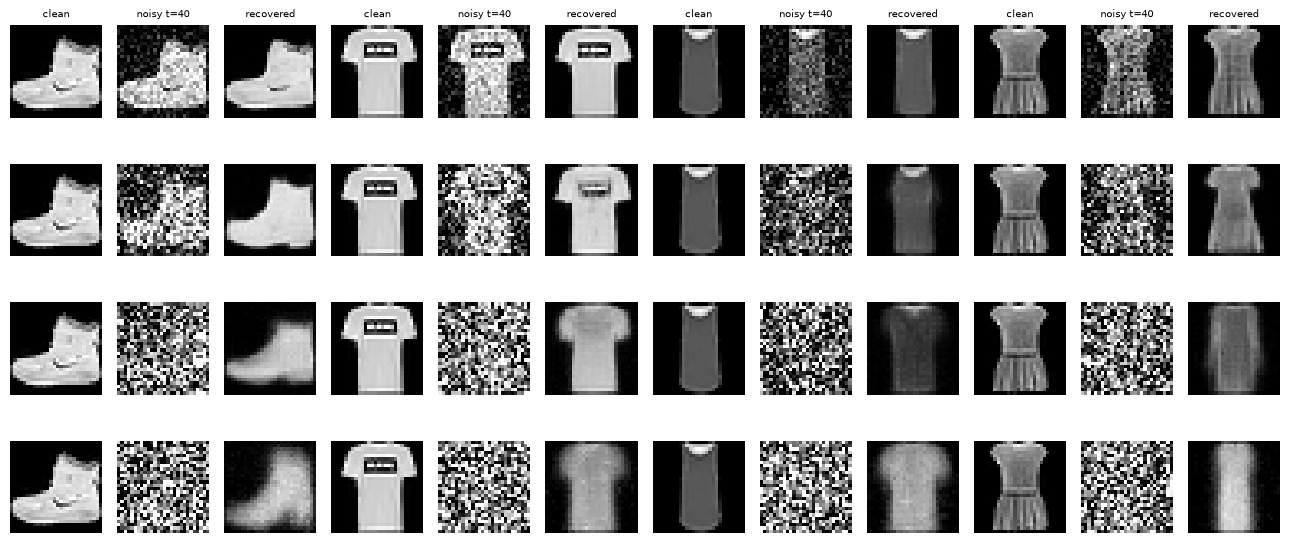

At low t the recovery is near-perfect. At high t it is a plausible garment
rather than the original one. The information is genuinely gone, and the
model is inventing. That is exactly the behaviour sampling exploits.


In [13]:
dit.eval()
show_t = [40, 120, 220, 320]
n_show = 4
x0 = X[:n_show].to(device)
y0 = Y[:n_show].to(device)

fig, axes = plt.subplots(len(show_t), n_show * 3, figsize=(13, 1.5 * len(show_t)))
for r, t_val in enumerate(show_t):
    t = torch.full((n_show,), t_val, device=device, dtype=torch.long)
    noise = torch.randn_like(x0)
    xt = forward_diffuse(x0, t, noise)
    with torch.no_grad():
        eps_pred = dit(xt, t, y0)
    ab = alpha_bar.to(device)[t][:, None, None, None]
    x0_hat = ((xt - (1 - ab).sqrt() * eps_pred) / ab.sqrt()).clamp(-1, 1)

    for k in range(n_show):
        for j, (im, lbl) in enumerate(((x0[k], "clean"), (xt[k], f"noisy t={t_val}"),
                                       (x0_hat[k], "recovered"))):
            ax = axes[r, k * 3 + j]
            ax.imshow(im[0].cpu(), cmap="gray", vmin=-1, vmax=1); ax.axis("off")
            if r == 0:
                ax.set_title(lbl, fontsize=7)
plt.tight_layout(); plt.show()

print("At low t the recovery is near-perfect. At high t it is a plausible garment")
print("rather than the original one. The information is genuinely gone, and the")
print("model is inventing. That is exactly the behaviour sampling exploits.")

---
# Module 7 — Reverse Sampling: Static → Clothing

📐 **The math**, unchanged from Chapter 8, which is the point of this whole
chapter. The sampler does not know or care that the denoiser is now a
Transformer:

$$ x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{\beta_t}{\sqrt{1 - \bar\alpha_t}}\, \varepsilon_\theta(x_t, t, c)\right) + \sigma_t z, \qquad z \sim \mathcal{N}(0, I) $$

with $\sigma_t^2 = \tilde\beta_t = \beta_t \frac{1 - \bar\alpha_{t-1}}{1 - \bar\alpha_t}$
and no noise added on the final step.


sampled 40 images in 2.6s (400 model evaluations x 2 for guidance)


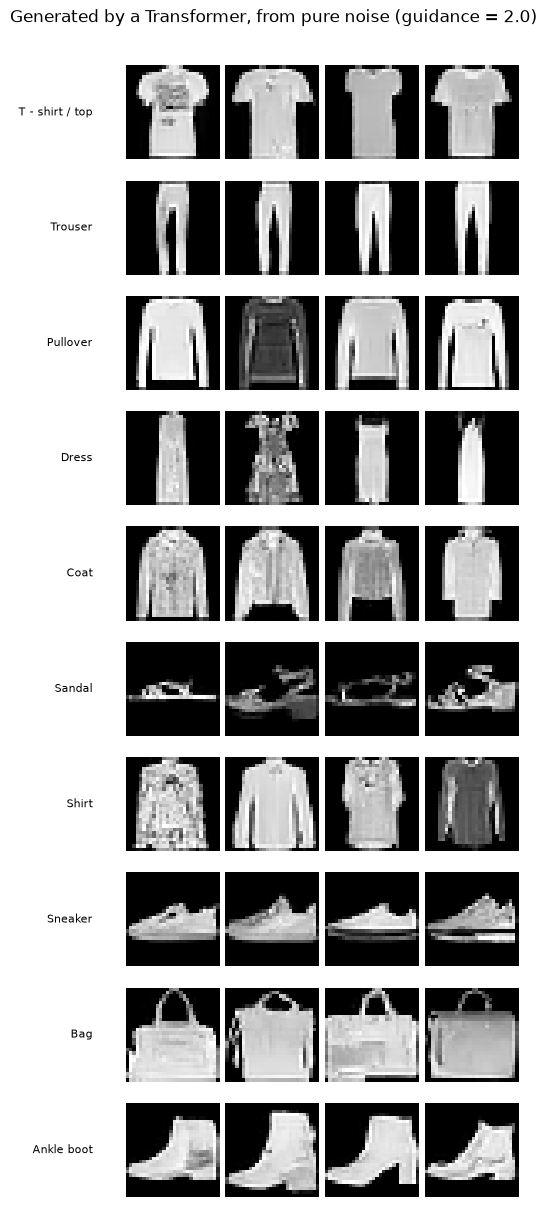

In [14]:
@torch.no_grad()
def sample(model, y, guidance=1.0, seed=0, return_trajectory=False):
    '''DDPM ancestral sampling with optional classifier-free guidance.'''
    model.eval()
    g = torch.Generator(device=device).manual_seed(seed)
    n = len(y)

    ab, al, be = alpha_bar.to(device), alphas.to(device), betas.to(device)
    y_null = torch.full_like(y, N_CLASSES)

    x = torch.randn(n, CHANNELS, IMG_SIZE, IMG_SIZE, device=device, generator=g)
    traj = []

    for t in reversed(range(T)):
        t_batch = torch.full((n,), t, device=device, dtype=torch.long)

        if guidance == 1.0:
            eps = model(x, t_batch, y)
        else:
            eps_cond = model(x, t_batch, y)
            eps_uncond = model(x, t_batch, y_null)
            eps = eps_uncond + guidance * (eps_cond - eps_uncond)     # Module 8

        mean = (x - be[t] / (1 - ab[t]).sqrt() * eps) / al[t].sqrt()
        if t > 0:
            var = be[t] * (1 - ab[t - 1]) / (1 - ab[t])
            x = mean + var.sqrt() * torch.randn(x.shape, device=device, generator=g)
        else:
            x = mean

        if return_trajectory and t % 50 == 0:
            traj.append(x.clamp(-1, 1).cpu())

    return (x.clamp(-1, 1), traj) if return_trajectory else x.clamp(-1, 1)


y_grid = torch.arange(N_CLASSES, device=device).repeat_interleave(4)
t0 = time.time()
samples = sample(dit, y_grid, guidance=2.0, seed=0)
print(f"sampled {len(samples)} images in {time.time() - t0:.1f}s "
      f"({T} model evaluations x 2 for guidance)")

fig, axes = plt.subplots(N_CLASSES, 4, figsize=(5.2, 12))
for row in range(N_CLASSES):
    for col in range(4):
        ax = axes[row, col]
        ax.imshow(samples[row * 4 + col, 0].cpu(), cmap="gray", vmin=-1, vmax=1)
        ax.axis("off")
    axes[row, 0].text(-0.35, 0.5, CLASS_NAMES[row], transform=axes[row, 0].transAxes,
                      ha="right", va="center", fontsize=8)
fig.suptitle("Generated by a Transformer, from pure noise (guidance = 2.0)", y=1.005)
plt.tight_layout(); plt.show()

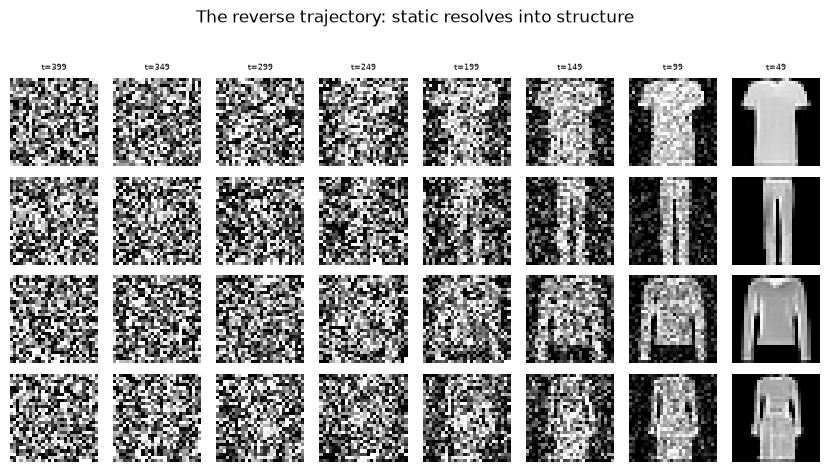

In [15]:
_, trajectory = sample(dit, torch.arange(8, device=device), guidance=2.0, seed=1,
                       return_trajectory=True)

fig, axes = plt.subplots(4, len(trajectory), figsize=(1.05 * len(trajectory), 4.6))
for r in range(4):
    for c, step in enumerate(trajectory):
        axes[r, c].imshow(step[r, 0], cmap="gray", vmin=-1, vmax=1)
        axes[r, c].axis("off")
        if r == 0:
            axes[r, c].set_title(f"t={T - 1 - c * 50}", fontsize=6)
fig.suptitle("The reverse trajectory: static resolves into structure", y=1.02)
plt.tight_layout(); plt.show()

---
# Module 8 — Classifier-Free Guidance, on a Transformer

🧠 **The intuition**, recalled from Chapter 8. During training we replaced 10% of
labels with a **null class**, so the same weights learned both a conditional and
an unconditional model. At sampling time, run both and *extrapolate away* from
the unconditional prediction, pushing the sample further in the direction the
class label points than the conditional model alone would go.

📐 **The math:**

$$ \tilde\varepsilon_\theta(x_t, t, c) = \varepsilon_\theta(x_t, t, \varnothing) + w \cdot \big(\varepsilon_\theta(x_t, t, c) - \varepsilon_\theta(x_t, t, \varnothing)\big) $$

$w = 0$ ignores the label entirely, $w = 1$ is ordinary conditional sampling, and
$w > 1$ over-drives it. Exactly as before: the mechanism is orthogonal to the
architecture, which is why it transferred with no modification.


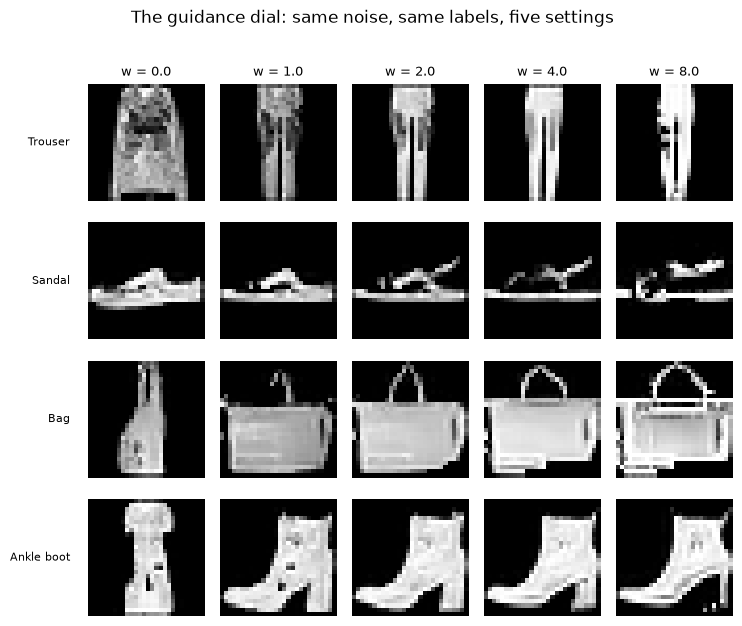

In [16]:
GUIDANCE = [0.0, 1.0, 2.0, 4.0, 8.0]
classes_to_show = [1, 5, 8, 9]        # trouser, sandal, bag, ankle boot
y_cfg = torch.tensor(classes_to_show, device=device)

fig, axes = plt.subplots(len(classes_to_show), len(GUIDANCE),
                         figsize=(1.5 * len(GUIDANCE), 1.55 * len(classes_to_show)))
for col, w in enumerate(GUIDANCE):
    imgs = sample(dit, y_cfg, guidance=w, seed=7)
    for row in range(len(classes_to_show)):
        axes[row, col].imshow(imgs[row, 0].cpu(), cmap="gray", vmin=-1, vmax=1)
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(f"w = {w}", fontsize=9)
for row, cls in enumerate(classes_to_show):
    axes[row, 0].text(-0.15, 0.5, CLASS_NAMES[cls], transform=axes[row, 0].transAxes,
                      ha="right", va="center", fontsize=8)
fig.suptitle("The guidance dial: same noise, same labels, five settings", y=1.01)
plt.tight_layout(); plt.show()

## 8.1 Trying to measure the trade, and finding out why it is hard

🧠 The textbook claim is that guidance **trades diversity for fidelity**: samples
get cleaner and more prototypical, but 32 bags start looking like the same bag.
The pictures above are suggestive. Let us try to put a number on it, because the
attempt teaches something about measurement that the picture does not.

Two quantities, over 48 samples of a single class:

- **contrast**, the pixel standard deviation, which should *rise* with $w$
- **diversity**, the mean pairwise distance between samples, which should *fall*


     w   contrast   raw dist   contrast-free dist
   0.0      0.694      21.31                29.71
   1.0      0.739      21.52                27.94
   2.0      0.797      21.42                26.21
   4.0      0.835      22.27                26.20
   8.0      0.844      23.72                27.78


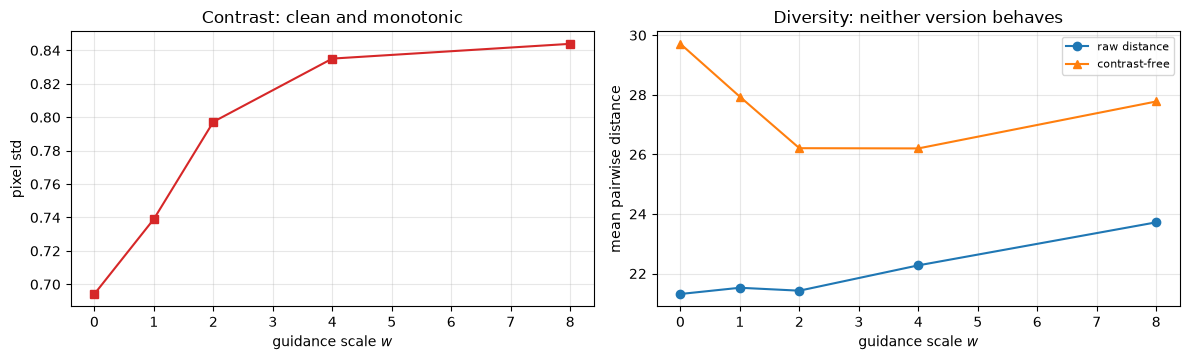

In [17]:
y_div = torch.full((48,), 8, device=device)          # 48 bags
rows = []
for w in GUIDANCE:
    imgs = sample(dit, y_div, guidance=w, seed=3)
    flat = imgs.reshape(len(imgs), -1)

    raw = (torch.cdist(flat, flat).sum() / (len(flat) * (len(flat) - 1))).item()

    # the same distance after standardizing each image, to remove the contrast effect
    normed = (flat - flat.mean(1, keepdim=True)) / flat.std(1, keepdim=True)
    scaled = (torch.cdist(normed, normed).sum() / (len(flat) * (len(flat) - 1))).item()

    rows.append((w, imgs.std().item(), raw, scaled))

print(f"{'w':>6}{'contrast':>11}{'raw dist':>11}{'contrast-free dist':>21}")
for w, sd, raw, scaled in rows:
    print(f"{w:>6}{sd:>11.3f}{raw:>11.2f}{scaled:>21.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.7))
axes[0].plot([r[0] for r in rows], [r[1] for r in rows], marker="s", color="tab:red")
axes[0].set_ylabel("pixel std"); axes[0].set_title("Contrast: clean and monotonic")

axes[1].plot([r[0] for r in rows], [r[2] for r in rows], marker="o", label="raw distance")
axes[1].plot([r[0] for r in rows], [r[3] for r in rows], marker="^", label="contrast-free")
axes[1].set_ylabel("mean pairwise distance")
axes[1].set_title("Diversity: neither version behaves")
axes[1].legend(fontsize=8)

for ax in axes:
    ax.set_xlabel("guidance scale $w$"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Read that carefully, because only one of the two predictions survived

**Contrast did exactly what it should**: it climbs monotonically with $w$. That
is the over-saturated look you get from cranking CFG too high in Stable
Diffusion, and here it is as a clean, reproducible curve.

**The diversity measurement failed**, and it is worth understanding how rather
than dropping it without comment. The raw pairwise distance *increases* with
guidance, the opposite of the claim. The reason is a confound: as $w$ rises,
contrast rises, so every image's pixels move further from the mean, so the
Euclidean distance between any two images grows *regardless of whether their
content became more similar*. The metric is measuring contrast wearing a
diversity costume. Standardizing each image first removes that confound and
gives a curve that dips and then rises again: better, and still not the clean
monotone decline the textbook describes.

**The honest conclusion is that pixel distance is the wrong instrument.** Two
images of visibly different bags can be close in pixel space; two nearly
identical bags shifted three pixels apart can be far. This is the same reason
per-pixel MSE gave blurry autoencoders back in Chapter 5: pixel space does not
measure perceptual similarity, and no amount of care with the arithmetic will
make it.

What the field actually uses is **distance in the feature space of a pretrained
network**, meaning FID and precision/recall metrics computed on Inception
features. Those do show the diversity collapse cleanly, and running one properly
would mean pulling in a pretrained classifier and thousands of samples per
setting, which is a notebook of its own.

So: trust the pictures for diversity, trust the curve for contrast, and treat
"guidance trades diversity for fidelity" as a claim you have seen qualitatively
and measured only halfway. That is a more accurate place to stand than a
confident-looking plot of the wrong quantity.


---
# Wrap-Up: Every Piece Built Earlier

| You built | The transferable lesson |
|---|---|
| Patchify / un-patchify | A denoiser needs both directions; patch size is the strongest quality lever in a DiT, and the reason this notebook costs what it does |
| Sinusoidal timestep embedding | Third appearance of one construction: noise level (Chapter 8), token position (Chapter 10), noise level again here |
| **AdaLN** | LayerNorm's $\gamma, \beta$ predicted from the conditioning instead of learned free. FiLM, applied to a Transformer |
| **adaLN-Zero** | Zero-init the modulation MLP so every block starts as the identity, verified exactly rather than asserted |
| The ablation | Additive conditioning is measurably worse; the extra parameters buy real capability. Reported with its caveat about unmatched parameter counts |
| DDPM sampling, unchanged | The sampler never learned that the denoiser stopped being a U-Net |
| Classifier-free guidance, unchanged | Guidance lives in the sampler; it transferred across architectures for free |
| A measurement that failed | Pixel distance cannot measure diversity: it tracks contrast instead. Knowing which of your numbers to distrust is part of the skill |

**What actually changed when the U-Net left.** The U-Net's core assumption was
that denoising is a *multi-scale, local* problem: downsample for context, keep
skip connections for detail, use convolutions throughout. The DiT drops all of
it. Every patch attends to every other patch at every layer: full resolution,
uniform, global. No hierarchy, no skips, no locality prior.

And it works better at scale, for the reason Chapter 11's wrap-up flagged. A ViT
starves on 50,000 labelled images because one class label per image is a thin
training signal. A DiT sees the *same* images as millions of distinct
(image, noise level, noise draw) triples and must predict a full-resolution
noise field for each, a vastly denser supervisory signal. The data-hunger that
made the ViT lose to a CNN in Chapter 11 simply is not the binding constraint
here, which is why DiTs overtook U-Nets at far more modest scale than ViTs
needed to overtake ResNets.

**The gap to Stable Diffusion 3 is now genuinely small**, and it is the same
list Chapter 8 gave you, with the architecture box now ticked:

1. **Run it in a latent space.** Train an autoencoder (Chapter 5) to compress
   512×512×3 into 64×64×4, then run this entire notebook *inside* that latent
   space. The "L" in latent diffusion. Your `x_embed` layer takes 4-channel
   patches instead of 1-channel ones; nothing else changes.
2. **Condition on text instead of a class index.** Replace
   `nn.Embedding(n_classes + 1, d)` with a frozen T5 or CLIP encoder. For a
   single pooled vector, adaLN-Zero handles it unchanged; for per-token text
   features you add **cross-attention**, the same attention you built in
   Chapter 9, with $K$ and $V$ coming from the text sequence instead of the
   image. The null class becomes the empty string, which is what a
   negative-prompt box edits.
3. **Scale.** DiT-XL/2 is 28 blocks at $d = 1152$; ours is 6 at 256. Same code.

**Nothing in this chapter was new except the conditioning.** The patch
embedding came from Chapter 11, the block from Chapter 10, the attention from
Chapter 9, the diffusion process from Chapter 8, and the "start as the identity"
initialization from Chapter 3. Only adaLN-Zero had to be invented, and it is
twenty lines. That is the argument for building things in this order.

**One thing the DiT still cannot do**, and it is the thing everyone actually
wants from a generative image model: take an instruction. Ours is conditioned on
a class *index*, an integer from 0 to 9, chosen from a list fixed before
training. Item 2 in the list above waves at the fix ("replace the embedding with
a frozen text encoder"), but that encoder has to come from somewhere, and it has
to have learned to put a sentence and a picture in the same space.

Nothing built so far can do that. Every model in this curriculum has learned
about images from labels you supplied, and a label cannot say "a dark narrow
boot". Learning from **image–text pairs** instead is a different objective with
a different failure mode, and it is where the next chapter starts.
